# LM vs. Bayes fit

In [23]:
# imports
from importlib import reload
from importlib.resources import files
import os, sys
import numpy as np

from scipy.optimize import curve_fit

import pandas
import seaborn as sns
from matplotlib import pyplot as plt

from scipy.interpolate import interp1d

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting as oc_plotting

from bing.models import anw as bing_anw
from bing.models import bbnw as bing_bbnw
from bing import inference as bing_inf
from bing import rt as bing_rt
from bing import chisq_fit
from bing.models import utils as model_utils
from bing import plotting as bing_plot

import anly_utils

sys.path.append(os.path.abspath("../../bing_2.0/Analysis/py"))
import anly_utils_20
import param as param20

In [3]:
#%matplotlib ipympl

# Load

## L23

In [4]:
ds = loisel23.load_ds(4,0)

### Unpack

In [5]:
l23_wave = ds.Lambda.data
l23_Rrs = ds.Rrs.data
a = ds.a.data
bb = ds.bb.data
adg = ds.ag.data + ds.ad.data
ag = ds.ag.data
ad = ds.ad.data
aph = ds.aph.data
anw = ds.anw.data

## Models

In [19]:
p = param20.p_ntuple(['ExpBricaud', 'Pow'], 
        set_Sdg=False, sSdg=0.002, beta=1., 
        add_noise=True, wv_min=400., wv_max=700.)
odict = anly_utils_20.prep_l23_data(
    idx, wv_min=p.wv_min, wv_max=p.wv_max)
l23_wave = odict['true_wave']

model_wave = anly_utils_20.pace_wave(
    wv_min=p.wv_min, wv_max=p.wv_max)
use_model_names = p.model_names.copy()
models = model_utils.init(use_model_names, model_wave)

## Fits

In [6]:
idx = 2773

### LM

In [28]:
fit_file = anly_utils.chain_filename(
        ['ExpBricaud', 'Pow'], 'PACE', True, idx=idx,
        PACE=False, use_LM=True)
d_LM = np.load(fit_file)
assert np.all(model_wave == d_LM['wave'])
fit_file

'../Analysis/Fits/BING_LM_ExpBricaudPow_2773_NP.npz'

### Bayes

In [29]:
bfit_file = anly_utils.chain_filename(
        ['ExpBricaud', 'Pow'], 'PACE', True, idx=idx,
        PACE=False, use_LM=False)
d_B = np.load(bfit_file)
bfit_file

'../Analysis/Fits/BING_ExpBricaudPow_2773_NP.npz'

### Checks

In [35]:
assert np.all(d_LM['obs_Rrs'] == d_B['obs_Rrs'])
assert np.all(d_LM['varRrs'] == d_B['varRrs'])

# Plot em

## LM

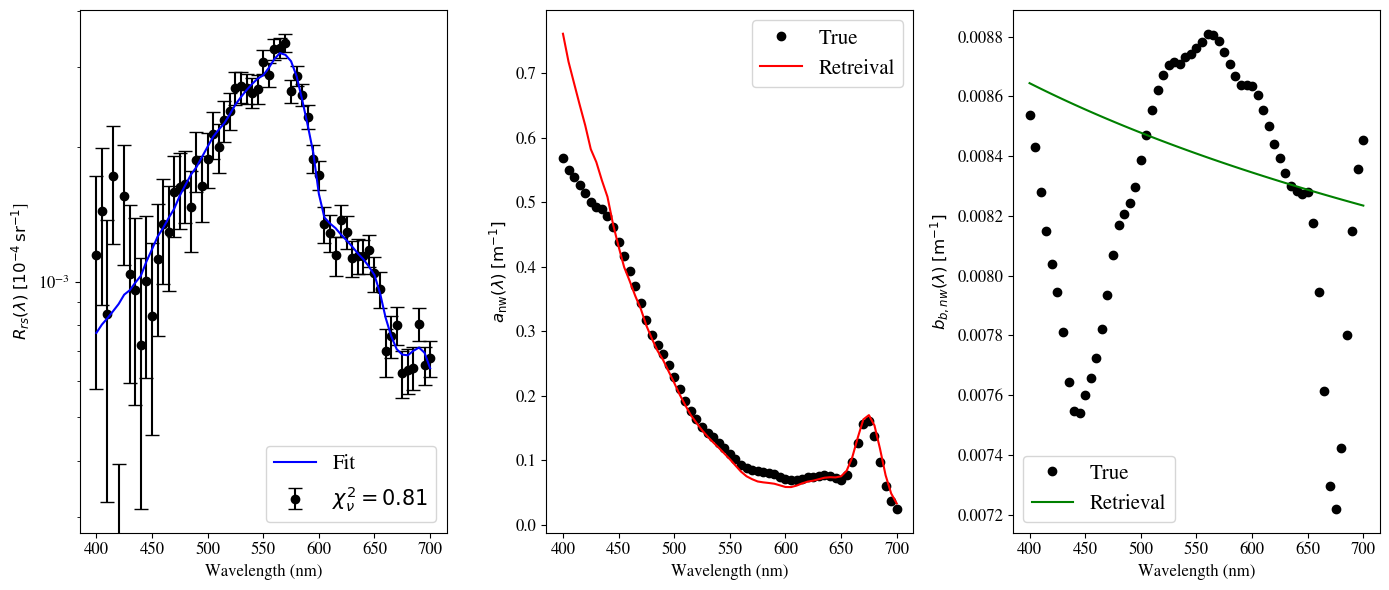

In [37]:
reload(bing_plot)
_, LM_Rrs = bing_plot.show_fits(
    models, d_LM['ans'], 
    odict['Chl'], odict['Y'],
    Rrs_true=dict(wave=model_wave, spec=d_LM['obs_Rrs'], var=d_LM['varRrs']),
    anw_true=dict(wave=l23_wave, spec=odict['anw']),
    bbnw_true=dict(wave=l23_wave, spec=odict['bbnw']),
    perc=(16, 84),  
    )
plt.show()

## Bayes

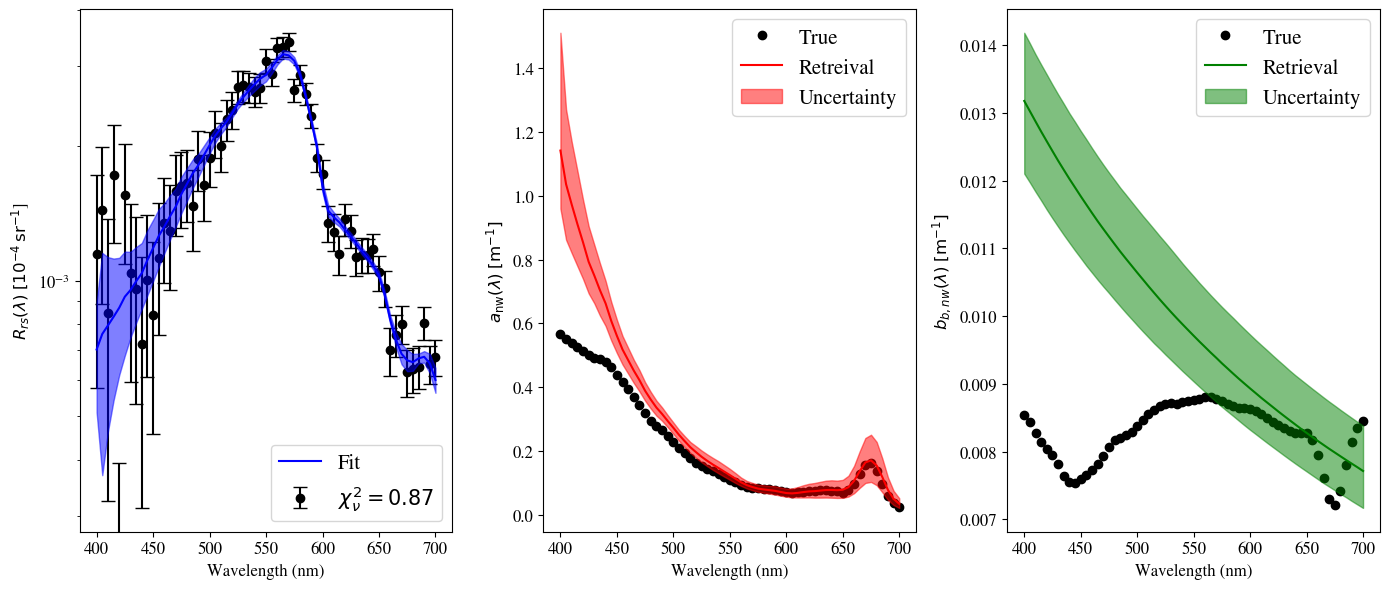

In [38]:
_, B_Rrs = bing_plot.show_fits(
    models, d_B['chains'], 
    odict['Chl'], odict['Y'],
    Rrs_true=dict(wave=model_wave, spec=d_B['obs_Rrs'], var=d_B['varRrs']),
    anw_true=dict(wave=l23_wave, spec=odict['anw']),
    bbnw_true=dict(wave=l23_wave, spec=odict['bbnw']),
    perc=(16, 84),  
    )
plt.show()

## Compare the two fits

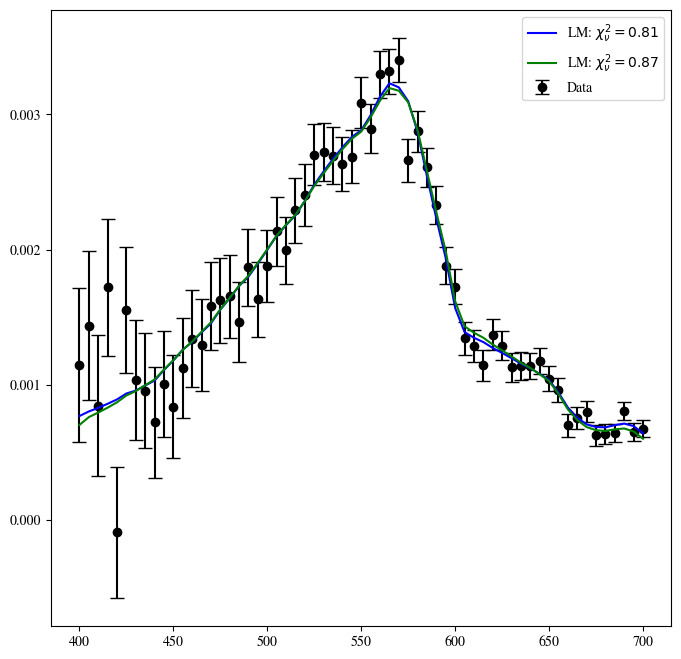

In [48]:
Rrs_true=dict(wave=model_wave, spec=d_B['obs_Rrs'], var=d_B['varRrs'])
wave = l23_wave

fig = plt.figure(figsize=(8,8))
ax_R = plt.gca()
# Calcualte chi^2
Rsig=np.sqrt(Rrs_true['var'])
ax_R.errorbar(Rrs_true['wave'], Rrs_true['spec'], 
    yerr=Rsig, color='k', fmt='o', capsize=5,
    label='Data')

# LM
for clr, lbl, model_Rrs in zip(['b', 'g'], ['LM', 'B'], [LM_Rrs, B_Rrs]):
    f = interp1d(wave, model_Rrs)
    mod_R = f(Rrs_true['wave'])
    chi2 = np.sum((Rrs_true['spec']-mod_R)**2 / Rsig**2)
    nparam = models[0].nparam + models[1].nparam
    red_chi2 = chi2 / (Rsig.size-nparam)
    #
    ax_R.plot(wave, model_Rrs, '-', color=clr, label='LM: '+r'$\chi^2_\nu = '+f'{red_chi2:0.2f}'+r'$', 
              zorder=10)

ax_R.legend()

# 
plt.show()